# 6.3.2 Z变换与精确采样

## 学习目标与先修知识

能从区间积分推导零阶保持（zero-order hold，ZOH）下的精确采样（sampling）模型（model）；写出单侧 Z 变换（unilateral Z-transform）的初值（initial condition）项和因果脉冲索引，区分采样周期与 Euler 求解步长。

先修：6.3.1 的初值响应与传递函数（transfer function）、2.4 的显式 Euler 方法。[复习上一节](01-LTI假设与Laplace表示.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

输送设备每隔 h 个时间单位设置一次流率（flow rate），中间保持不变。用同样间隔观察所追踪物质总量（tracked amount），精确离散模型和一次 Euler 更新为什么可能一个始终非负、另一个却交替变号？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GRAY = '#008bfb', '#ff0051', '#555555'

## 初步实验

In [2]:
k=1.0
rows=[(h,math.exp(-k*h),1-k*h) for h in [0.25,1.0,1.5,2.5]]
display(Markdown(show_table(['间隔 h / T','精确保留倍数','Euler 保留倍数'],rows)))

| 间隔 h / T | 精确保留倍数 | Euler 保留倍数 |
| --- | --- | --- |
| 0.25 | 0.778801 | 0.75 |
| 1 | 0.367879 | 0 |
| 1.5 | 0.22313 | -0.5 |
| 2.5 | 0.082085 | -1.5 |

## 模型假设

连续模型 $\dot x=-kx+u(t)$，总量 $x$ 单位 U，输入（input）率 $u$ 单位 U/T，$k\ge0$ 单位 $1/T$。记 $x[n]=x(nh)$，$h>0$ 单位 T，$u[n]$ 在 $[nh,(n+1)h)$ 上固定。$x[n]$ 是区间开始的状态（state），不能与区间末状态混用。总量例子的输入、初值均非负；数值结果保留原值以检查更新是否保持非负性（nonnegativity）。

精确采样模型以区间保持为假设；若实际输入在区间内改变，仅给一个采样点的值不能决定积分（definite integral）。本节没有采样或测量误差，目的是分清模型表示与计算近似。

## 数学解释与推导

### 同一间隔，两个不同更新式

对单个区间积分得到
$$x[n+1]=a x[n]+b u[n],\quad a=e^{-kh},\quad b=\int_0^h e^{-k(h-\tau)}d\tau=\begin{cases}(1-e^{-kh})/k,&k>0,\\h,&k=0.\end{cases}$$
$a$ 无单位，$b$ 单位 T。这是精确更新，不需要“把 h 取得足够小”；前提是模型和输入保持假设成立。对同一个连续模型，显式 Euler 近似给出 $x[n+1]=(1-kh)x[n]+hu[n]$，系数只在 $kh$ 小时近似精确系数。

$k>0$ 时精确无输入因子满足 $0<a<1$。Euler 振幅（amplitude）衰减要求 $|1-kh|<1$，即 $0<kh<2$；若要求所有非负状态与输入下一步仍非负，还需 $kh\le1$。$kh=1.5$ 时会衰减变号，$kh=2.5$ 时变号且幅度增长。$kh=2$ 的无输入幅度不衰减。$k=0$ 时两者都是积分器，不能套用 $0<a<1$。

**采样周期 h 决定哪些时刻有观测（observation），求解步长 δ 决定数值积分如何逼近。** 可以在两次观测之间做 $m$ 次 $\delta=h/m$ 的 Euler 更新，再只保存采样时刻；这改善求解误差，但不会增加真实测量信息，也不消除采样混叠（aliasing）。

### 初值和一个样本的延迟

定义 $X(z)=\sum_{n=0}^{\infty}x[n]z^{-n}$，$z$ 无单位。改变求和索引：
$$\sum_{n=0}^{\infty}x[n+1]z^{-n}=z\left(X(z)-x[0]\right).$$
所以
$$X(z)=\frac{zx[0]}{z-a}+\frac{b}{z-a}U(z).$$
零初值传递函数为 $H(z)=b/(z-a)=bz^{-1}/(1-az^{-1})$。输入 $u[0]=1$、其余为零时，$x[0]=0$、$x[1]=b$、$x[2]=ba$，因此因果脉冲响应（impulse response）是 $g[0]=0$、$g[n]=ba^{n-1}$（$n\ge1$）。这里“1”表示一个区间的单位输入率，不是连续时间瞬时输入 1 U；矩形脉冲的总输入量为 h U。

几何级数要求 $|a/z|<1$，故 ROC 为 $|z|>|a|$；极点（pole）在 $a$。$k>0$ 对应极点在单位圆内，$\sum_{n\ge0}|g[n]|=b/(1-a)=1/k$，与连续系统的恒定输入增益（gain）一致。$H=b/(z-a)$ 没有有限零点（zero）；不要把等价式中的 $z^{-1}$ 单独误当有限零点。换用“本区间末输出（output）”的定义会改变索引，必须先说明输出时刻。

连续极点 $s=-k$ 经精确采样对应 $z=e^{sh}=e^{-kh}$；Euler 是 $z=1+sh$。两者都在表示离散响应，却不是同一个映射。

## 核心实现

把每个量的计算写在本节，返回普通数值与列表；先检查定义，再用独立关系核对结果。

In [3]:
def sampled_response(k: float, step: float, initial: float,
                     inputs: list[float]) -> tuple[list[float], list[float]]:
    if k < 0 or step <= 0:
        raise ValueError('k 须非负，采样间隔须为正')
    a = math.exp(-k*step)
    b = step if k == 0 else -math.expm1(-k*step)/k
    exact, euler = [float(initial)], [float(initial)]
    for value in inputs:
        exact.append(a*exact[-1]+b*value)
        euler.append((1-k*step)*euler[-1]+step*value)
    return exact, euler

## 对照实验

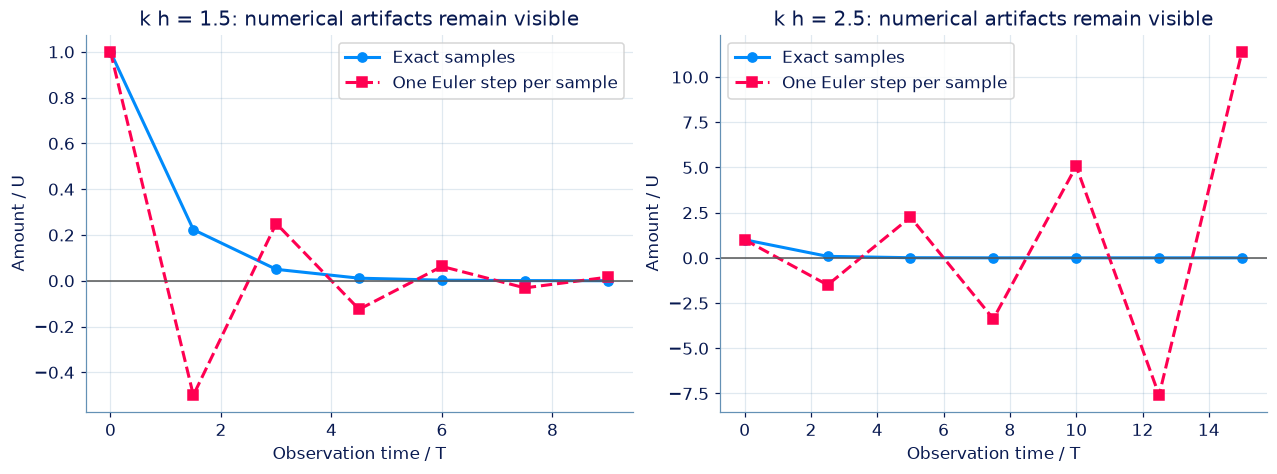

| 子步数 | 求解步长 / T | 2.5 T 时总量 / U | 绝对误差 / U |
| --- | --- | --- | --- |
| 1 | 2.5 | -1.5 | 1.58208 |
| 5 | 0.5 | 0.03125 | 0.050835 |
| 25 | 0.1 | 0.0717898 | 0.0102952 |
| 125 | 0.02 | 0.0800312 | 0.00205377 |

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11.5,4.2))
for ax,h in zip(axes,[1.5,2.5]):
    exact,euler=sampled_response(1.0,h,1.0,[0.0]*6)
    times=np.arange(7)*h
    ax.plot(times,exact,'o-',color=BLUE,label='Exact samples')
    ax.plot(times,euler,'s--',color=PINK,label='One Euler step per sample')
    ax.axhline(0,color=GRAY,lw=1)
    ax.set(xlabel='Observation time / T',ylabel='Amount / U',title=f'k h = {h:g}: numerical artifacts remain visible')
    ax.legend()
plt.show()
# 同一观测间隔 h=2.5，以更小求解步长逼近一次区间积分。
rows=[]
for m in [1,5,25,125]:
    approximation=(1-2.5/m)**m
    rows.append((m,2.5/m,approximation,abs(approximation-math.exp(-2.5))))
display(Markdown(show_table(['子步数','求解步长 / T','2.5 T 时总量 / U','绝对误差 / U'],rows)))

## 结果解释

左图的 Euler 轨迹（trajectory）振幅在减小，仍违反非负总量约束；右图同时违反稳定性与非负性（nonnegativity）。需要分别检查偏差的放大因子和总量的符号。表格只改变求解子步，观察时刻始终为 2.5 T。精确模型能使用大间隔，并不意味着大间隔能识别区间内发生的所有输入变化。继续比较：[时域与极点联动](http://127.0.0.1:8000/chapters/06-03-LTI%20系统、Laplace%20与%20Z%20变换/explore/)。

### 独立核对与边界

In [5]:
exact,euler=sampled_response(0.4,0.5,0.0,[1.0,0.0,0.0])
a=math.exp(-0.2);b=(1-a)/0.4
assert np.allclose(exact,[0,b,b*a,b*a*a])
exact0,euler0=sampled_response(0.,0.5,2.,[1.,2.,0.])
assert exact0==euler0==[2.,2.5,3.5,3.5]
# 常输入下，递推与连续闭式在所有采样时刻一致。
constant,_=sampled_response(0.4,0.5,3.,[1.]*12)
assert np.allclose(constant,2.5+0.5*np.exp(-0.4*np.arange(13)*0.5))
# 精确更新把两个半区间合并，保持同一输入，结果仍相同。
full,_=sampled_response(0.4,1.,3.,[2.])
half,_=sampled_response(0.4,0.5,3.,[2.,2.])
assert math.isclose(full[-1],half[-1],rel_tol=1e-13)
display(Markdown('脉冲索引、零清除、连续闭式和区间合并核对均通过。'))

脉冲索引、零清除、连续闭式和区间合并核对均通过。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：相同采样间隔不等于相同离散模型

每段输入（input）在整个采样（sampling）区间保持常数。返回同一单室模型（one-compartment model）的精确采样轨迹（trajectory）与显式Euler近似。

**函数与代码模板**

```python
def solve(
    k: float,
    step: float,
    initial: float,
    inputs: list[float],
) -> tuple[list[float], list[float]]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `k` | `float` | 清除系数（elimination rate constant）。 | 1/T |
| `step` | `float` | 每段输入保持的时长/采样间隔。 | T |
| `initial` | `float` | 起点所追踪物质总量（tracked amount）。 | U |
| `inputs` | `list[float]` | 每个区间内保持不变的输入流率（flow rate）。 | U/T |

**返回值**

按以下顺序返回元组：(exact, euler)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `exact` | `list[float]` | 精确零阶保持（zero-order hold，ZOH）轨迹，含初态。 | U |
| `euler` | `list[float]` | 显式Euler轨迹，含初态且保留负值。 | U |

**计算规则**

a=exp(−k*step)，b=(1−a)/k；k=0时b=step。精确更新A_next=a*A+b*u。Euler更新A_next=(1−k*step)*A+step*u。各自递推，均含初态，不裁剪负值。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 0≤k≤1；0.01≤step≤4；0≤initial≤20；0—12段输入，各0≤u≤5。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| k | 清除系数（elimination rate constant）。 | 0.5 | 1/T |
| step | 每段输入保持的时长/采样间隔。 | 1 | T |
| initial | 起点所追踪物质总量（tracked amount）。 | 4 | U |
| inputs | 每个区间内保持不变的输入流率（flow rate）。 | [0.0, 2.0] | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
k = 0.5
step = 1.0
initial = 4.0
inputs = [0.0, 2.0]

result = solve(k, step, initial, inputs)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| exact | 精确零阶保持（zero-order hold，ZOH）轨迹，含初态。 | [4.0, 2.4261226388505337, 3.0453951258352356] | U |
| euler | 显式Euler轨迹，含初态且保留负值。 | [4.0, 2.0, 3.0] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([4.0,
                    2.4261226388505337,
                    3.0453951258352356],
                   [4.0, 2.0, 3.0])
```

**样例解释**

第一步无输入时精确值4e⁻⁰·⁵≈2.42612 U，Euler为2 U；第二步再分别使用各自的前一步状态（state）。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：相同采样间隔不等于相同离散模型](http://127.0.0.1:8000/chapters/06-03-LTI%20%E7%B3%BB%E7%BB%9F%E3%80%81Laplace%20%E4%B8%8E%20Z%20%E5%8F%98%E6%8D%A2/practice/?question=p06-sampled-response)

### 第 2 题 · 单项选择题：Z变换中的一拍延迟

零初态差分模型（model） x[n+1]=a*x[n]+b*u[n]，n≥0。采用X(z)=Σ_{n≥0}x[n]z⁻ⁿ，哪项正确？

- **A.** G(z)=b*z⁻¹/(1−a*z⁻¹)，因为u[0]最早影响x[1]。
- **B.** G(z)=b/(1−a*z⁻¹)，而无需调整输出（output）索引。
- **C.** 非零x[0]也可直接删去。
- **D.** z只等于实时间n。

[作答：Z变换中的一拍延迟](http://127.0.0.1:8000/chapters/06-03-LTI%20%E7%B3%BB%E7%BB%9F%E3%80%81Laplace%20%E4%B8%8E%20Z%20%E5%8F%98%E6%8D%A2/practice/?question=p06-z-index)

### 第 3 题 · 多项选择题：离散极点与物理合理性

k>0、h>0，无输入（input）时精确因子exp(−kh)，Euler因子1−kh。哪些正确？

- **A.** Euler幅度衰减要求0<kh<2。
- **B.** Euler对所有非负初态保持非负要求kh≤1。
- **C.** 只要1−kh<1就保证幅度衰减。
- **D.** 精确因子总在(0,1)。

[作答：离散极点与物理合理性](http://127.0.0.1:8000/chapters/06-03-LTI%20%E7%B3%BB%E7%BB%9F%E3%80%81Laplace%20%E4%B8%8E%20Z%20%E5%8F%98%E6%8D%A2/practice/?question=p06-discrete-poles)

### 第 4 题 · 单项选择题：零清除系数如何取极限

k趋向0、保持h固定，精确区间系数b=(1−exp(−kh))/k满足什么？

- **A.** 必须抛弃k=0情形，因为分母为0。
- **B.** 极限（limit）系数仍具有1/T单位。
- **C.** b趋向h，得到按流量（flow）累积的积分器。
- **D.** b趋向0。

[作答：零清除系数如何取极限](http://127.0.0.1:8000/chapters/06-03-LTI%20%E7%B3%BB%E7%BB%9F%E3%80%81Laplace%20%E4%B8%8E%20Z%20%E5%8F%98%E6%8D%A2/practice/?question=p06-zero-clearance)

### 第 5 题 · 多项选择题：改变采样周期后系数怎样变化

同一k>0连续系统，两次实验都满足区间恒定输入（input）。将采样（sampling）周期h改为2h。哪些正确？

- **A.** 仅改变观察时刻、保持同一连续方程和实际输入轨迹（trajectory）时，真实动态不变。
- **B.** 精确状态（state）系数从a变成a²。
- **C.** 输入系数也必须重新按2h计算。
- **D.** 直接把Euler系数平方一定等于连续模型（model）的精确采样系数。

[作答：改变采样周期后系数怎样变化](http://127.0.0.1:8000/chapters/06-03-LTI%20%E7%B3%BB%E7%BB%9F%E3%80%81Laplace%20%E4%B8%8E%20Z%20%E5%8F%98%E6%8D%A2/practice/?question=p06-sampling-pole-map)

**进一步阅读**

[MIT 6.003 讲义](https://ocw.mit.edu/courses/6-003-signals-and-systems-fall-2011/pages/lecture-notes/)第 5、7 讲：Z 变换与连续系统的离散近似。本节从区间积分另行推导精确保持模型。